## 1. Cài đặt thư viện

In [36]:
!pip install -q transformers datasets evaluate nltk Pillow torch torchvision tqdm pycocoevalcap accelerate
!pip install -q accelerate
print('Cài đặt hoàn tất!')

Cài đặt hoàn tất!


## 2. Import thư viện

In [37]:
import os
import json
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    get_linear_schedule_with_warmup
)

import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cpu


##  3. Mount Google Drive & Cấu hình đường dẫn

In [38]:
import io

# ── Kaggle: dataset được mount sẵn tại /kaggle/input/ ────
DATASET_ROOT  = Path('/kaggle/input/datasets/hsankesara/flickr-image-dataset')
IMAGES_DIR    = DATASET_ROOT / 'flickr30k_images' / 'flickr30k_images'
CAPTIONS_FILE = DATASET_ROOT / 'flickr30k_images' / 'results.csv'

# Checkpoint lưu tại /kaggle/working/
CHECKPOINT_DIR = Path('/kaggle/working/blip_checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f'🖼️  Ảnh     : {IMAGES_DIR}')
print(f'📝 Captions: {CAPTIONS_FILE}')
print(f'💾 Checkpoint: {CHECKPOINT_DIR}')

# ── Cache toàn bộ ảnh vào RAM (tránh network I/O chậm) ──
print('\nCaching ảnh vào RAM...')
image_cache = {}
all_img_names = [p.name for p in IMAGES_DIR.glob('*.jpg')]
for img_name in tqdm(all_img_names, desc='Caching'):
    with open(IMAGES_DIR / img_name, 'rb') as f:
        image_cache[img_name] = f.read()
print(f'Cached {len(image_cache):,} ảnh vào RAM')

🖼️  Ảnh     : /kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/flickr30k_images
📝 Captions: /kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/results.csv
💾 Checkpoint: /kaggle/working/blip_checkpoints

Caching ảnh vào RAM...


Caching:   0%|          | 0/31783 [00:00<?, ?it/s]

Cached 31,783 ảnh vào RAM


Tổng quan Dataset:
Số ảnh được cache: 31,783
Images dir  : /kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/flickr30k_images
Captions file: /kaggle/input/datasets/hsankesara/flickr-image-dataset/flickr30k_images/results.csv


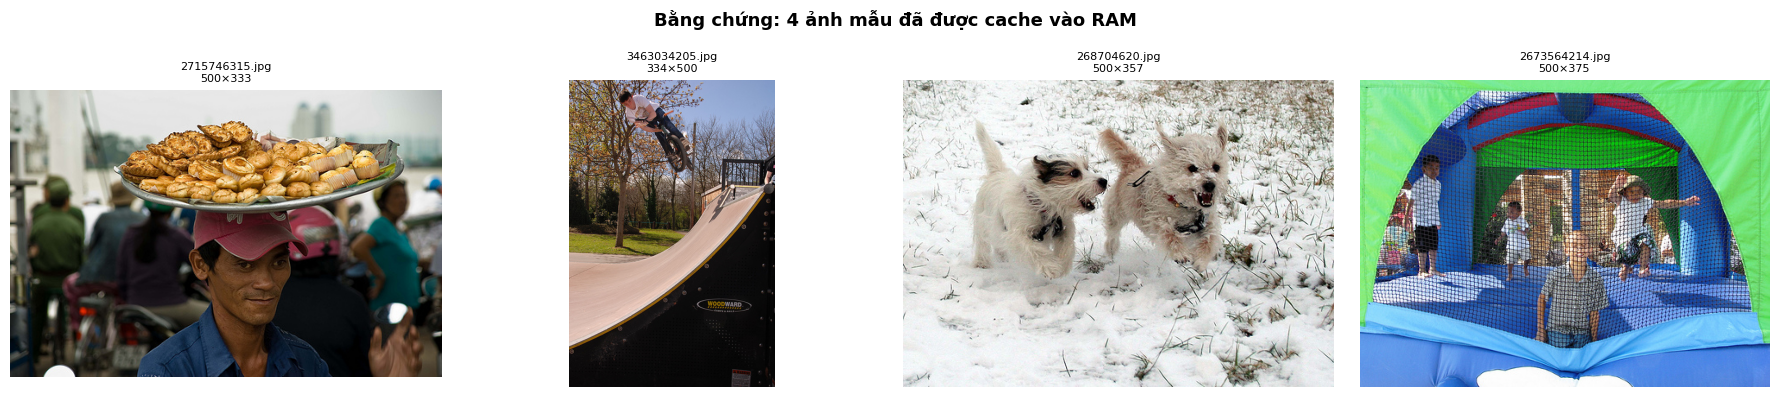

In [39]:
# Kiểm tra dataset 
print("Tổng quan Dataset:")
print(f"Số ảnh được cache: {len(image_cache):,}")
print(f"Images dir  : {IMAGES_DIR}")
print(f"Captions file: {CAPTIONS_FILE}")

# Hiển thị 4 ảnh mẫu
import io
sample_keys = list(image_cache.keys())[:4]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Bằng chứng: 4 ảnh mẫu đã được cache vào RAM', fontsize=13, fontweight='bold')
for ax, k in zip(axes, sample_keys):
    img = Image.open(io.BytesIO(image_cache[k])).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'{k}\n{img.size[0]}×{img.size[1]}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 🔍 4. Load & Khám phá Dataset

In [40]:
def load_flickr30k_captions(captions_file: Path) -> pd.DataFrame:
    rows = []
    ext = captions_file.suffix.lower()

    with open(captions_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('image'):  # bỏ header
                continue

            if '|' in line:                           # format 1
                parts = line.split('|')
                img_name, cap_idx, caption = parts[0], parts[1], '|'.join(parts[2:])
            elif '\t' in line:                        # format 3
                left, caption = line.split('\t', 1)
                img_name, cap_idx = left.split('#')
            else:                                     # format 2 (csv)
                parts = line.split(',', 2)
                img_name, cap_idx, caption = parts[0], parts[1], parts[2]

            rows.append({
                'image_name': img_name.strip(),
                'caption_idx': int(str(cap_idx).strip()),
                'caption': caption.strip()
            })

    return pd.DataFrame(rows)


df = pd.read_csv(
    CAPTIONS_FILE,
    sep='|',                  # delimiter thực tế
    skipinitialspace=True,    # bỏ khoảng trắng thừa sau dấu |
    header=0,
    names=['image_name', 'caption_idx', 'caption']
)

# Bỏ hàng header nếu bị đọc vào như data
df = df[df['caption_idx'].astype(str).str.strip().str.match(r'^\d+$')].copy()

# Ép kiểu
df['caption_idx'] = df['caption_idx'].astype(int)
df['image_name']  = df['image_name'].str.strip()
df['caption']     = df['caption'].str.strip()
df = df.reset_index(drop=True)

print(f'Tổng số dòng      : {len(df):,}')
print(f'Số ảnh unique     : {df["image_name"].nunique():,}')
print(f'Captions/ảnh      : {len(df) / df["image_name"].nunique():.1f}')
df.head(10)

Tổng số dòng      : 158,914
Số ảnh unique     : 31,783
Captions/ảnh      : 5.0


,image_name,caption_idx,caption
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...
1,1000092795.jpg,1,"Two young , White males are outside near many ..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .
5,10002456.jpg,0,Several men in hard hats are operating a giant...
6,10002456.jpg,1,Workers look down from up above on a piece of ...
7,10002456.jpg,2,Two men working on a machine wearing hard hats .
8,10002456.jpg,3,Four men on top of a tall structure .
9,10002456.jpg,4,Three men on a large rig .


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TRƯỚC — Dòng thô từ results.csv (chưa xử lý):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [0] 'image_name| comment_number| comment\n'
  [1] '1000092795.jpg| 0| Two young guys with shaggy hair look at their hands while hanging out i'
  [2] '1000092795.jpg| 1| Two young , White males are outside near many bushes .\n'
  [3] '1000092795.jpg| 2| Two men in green shirts are standing in a yard .\n'
  [4] '1000092795.jpg| 3| A man in a blue shirt standing in a garden .\n'
  [5] '1000092795.jpg| 4| Two friends enjoy time spent together .\n'

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SAU — DataFrame sau khi parse, strip, ép kiểu:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,image_name,caption_idx,caption
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...
1,1000092795.jpg,1,"Two young , White males are outside near many ..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SAU — Thống kê caption length (số từ/caption):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


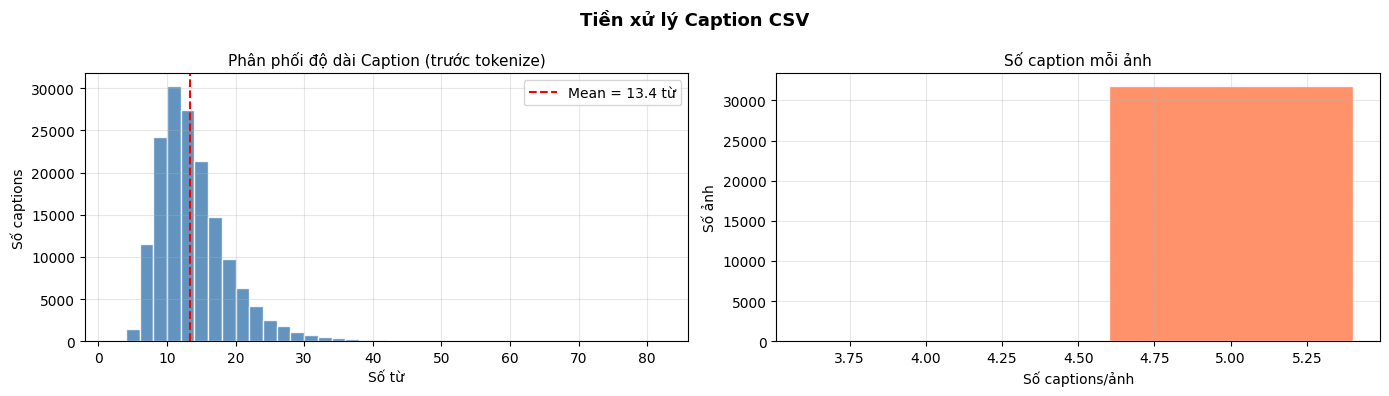

   Min / Mean / Max: 2 / 13.4 / 82 từ
   Tổng captions   : 158,914 | Unique ảnh: 31,783


In [41]:
# Xử lý Caption CSV — TRƯỚC và SAU khi parse
# đọc raw file
print("━" * 65)
print("TRƯỚC — Dòng thô từ results.csv (chưa xử lý):")
print("━" * 65)
with open(CAPTIONS_FILE, 'r', encoding='utf-8') as _f:
    _raw_lines = [next(_f) for _ in range(6)]
for i, l in enumerate(_raw_lines):
    print(f"  [{i}] {repr(l[:90])}")

print()
print("━" * 65)
print("SAU — DataFrame sau khi parse, strip, ép kiểu:")
print("━" * 65)
display(df[['image_name','caption_idx','caption']].head(5))

print()
print("━" * 65)
print("SAU — Thống kê caption length (số từ/caption):")
print("━" * 65)
_cap_len = df['caption'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Tiền xử lý Caption CSV', fontsize=13, fontweight='bold')

axes[0].hist(_cap_len, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(_cap_len.mean(), color='red', linestyle='--',
                label=f'Mean = {_cap_len.mean():.1f} từ')
axes[0].set_title('Phân phối độ dài Caption (trước tokenize)', fontsize=11)
axes[0].set_xlabel('Số từ'); axes[0].set_ylabel('Số captions')
axes[0].legend(); axes[0].grid(alpha=0.3)

_caps_per_img = df.groupby('image_name').size()
axes[1].bar(_caps_per_img.value_counts().index,
            _caps_per_img.value_counts().values,
            color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Số caption mỗi ảnh', fontsize=11)
axes[1].set_xlabel('Số captions/ảnh'); axes[1].set_ylabel('Số ảnh')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"   Min / Mean / Max: {_cap_len.min()} / {_cap_len.mean():.1f} / {_cap_len.max()} từ")
print(f"   Tổng captions   : {len(df):,} | Unique ảnh: {df['image_name'].nunique():,}")


In [42]:
# DataFrame captions đã load
print(f"DataFrame shape: {df.shape}")
print(f"   Cột: {list(df.columns)}")
print()
print("5 dòng đầu tiên:")
display(df.head(5))
print()
print(f"Mẫu caption: '{df['caption'].iloc[0]}'")


DataFrame shape: (158914, 3)
   Cột: ['image_name', 'caption_idx', 'caption']

5 dòng đầu tiên:


,image_name,caption_idx,caption
0,1000092795.jpg,0,Two young guys with shaggy hair look at their ...
1,1000092795.jpg,1,"Two young , White males are outside near many ..."
2,1000092795.jpg,2,Two men in green shirts are standing in a yard .
3,1000092795.jpg,3,A man in a blue shirt standing in a garden .
4,1000092795.jpg,4,Two friends enjoy time spent together .



Mẫu caption: 'Two young guys with shaggy hair look at their hands while hanging out in the yard .'


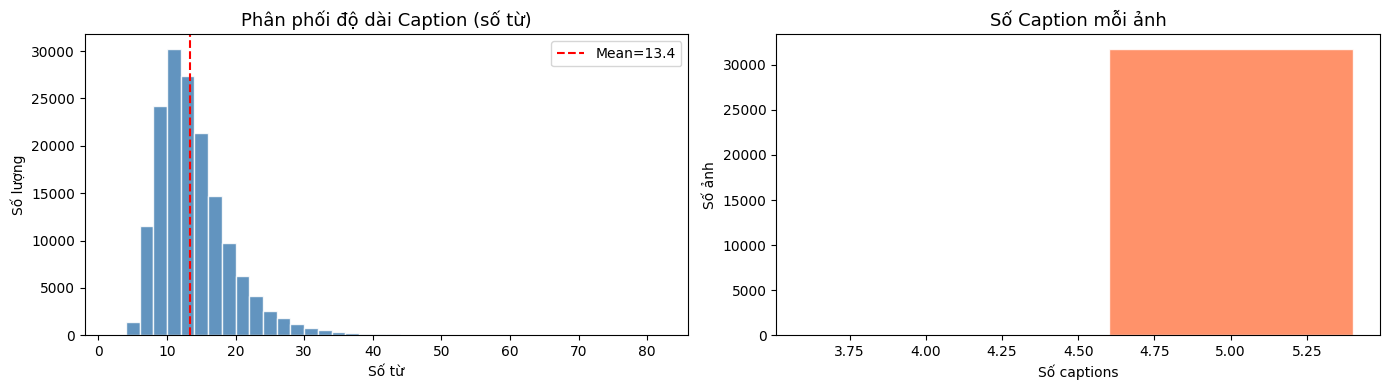

Caption ngắn nhất : 2 từ
Caption dài nhất  : 82 từ
Trung bình        : 13.4 từ


In [43]:
# Thống kê caption
df['caption_len'] = df['caption'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['caption_len'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Phân phối độ dài Caption (số từ)', fontsize=13)
axes[0].set_xlabel('Số từ'); axes[0].set_ylabel('Số lượng')
axes[0].axvline(df['caption_len'].mean(), color='red', linestyle='--',
                label=f'Mean={df["caption_len"].mean():.1f}')
axes[0].legend()

caps_per_img = df.groupby('image_name').size()
axes[1].bar(caps_per_img.value_counts().index, caps_per_img.value_counts().values,
            color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Số Caption mỗi ảnh', fontsize=13)
axes[1].set_xlabel('Số captions'); axes[1].set_ylabel('Số ảnh')

plt.tight_layout()
plt.show()

print(f'Caption ngắn nhất : {df["caption_len"].min()} từ')
print(f'Caption dài nhất  : {df["caption_len"].max()} từ')
print(f'Trung bình        : {df["caption_len"].mean():.1f} từ')

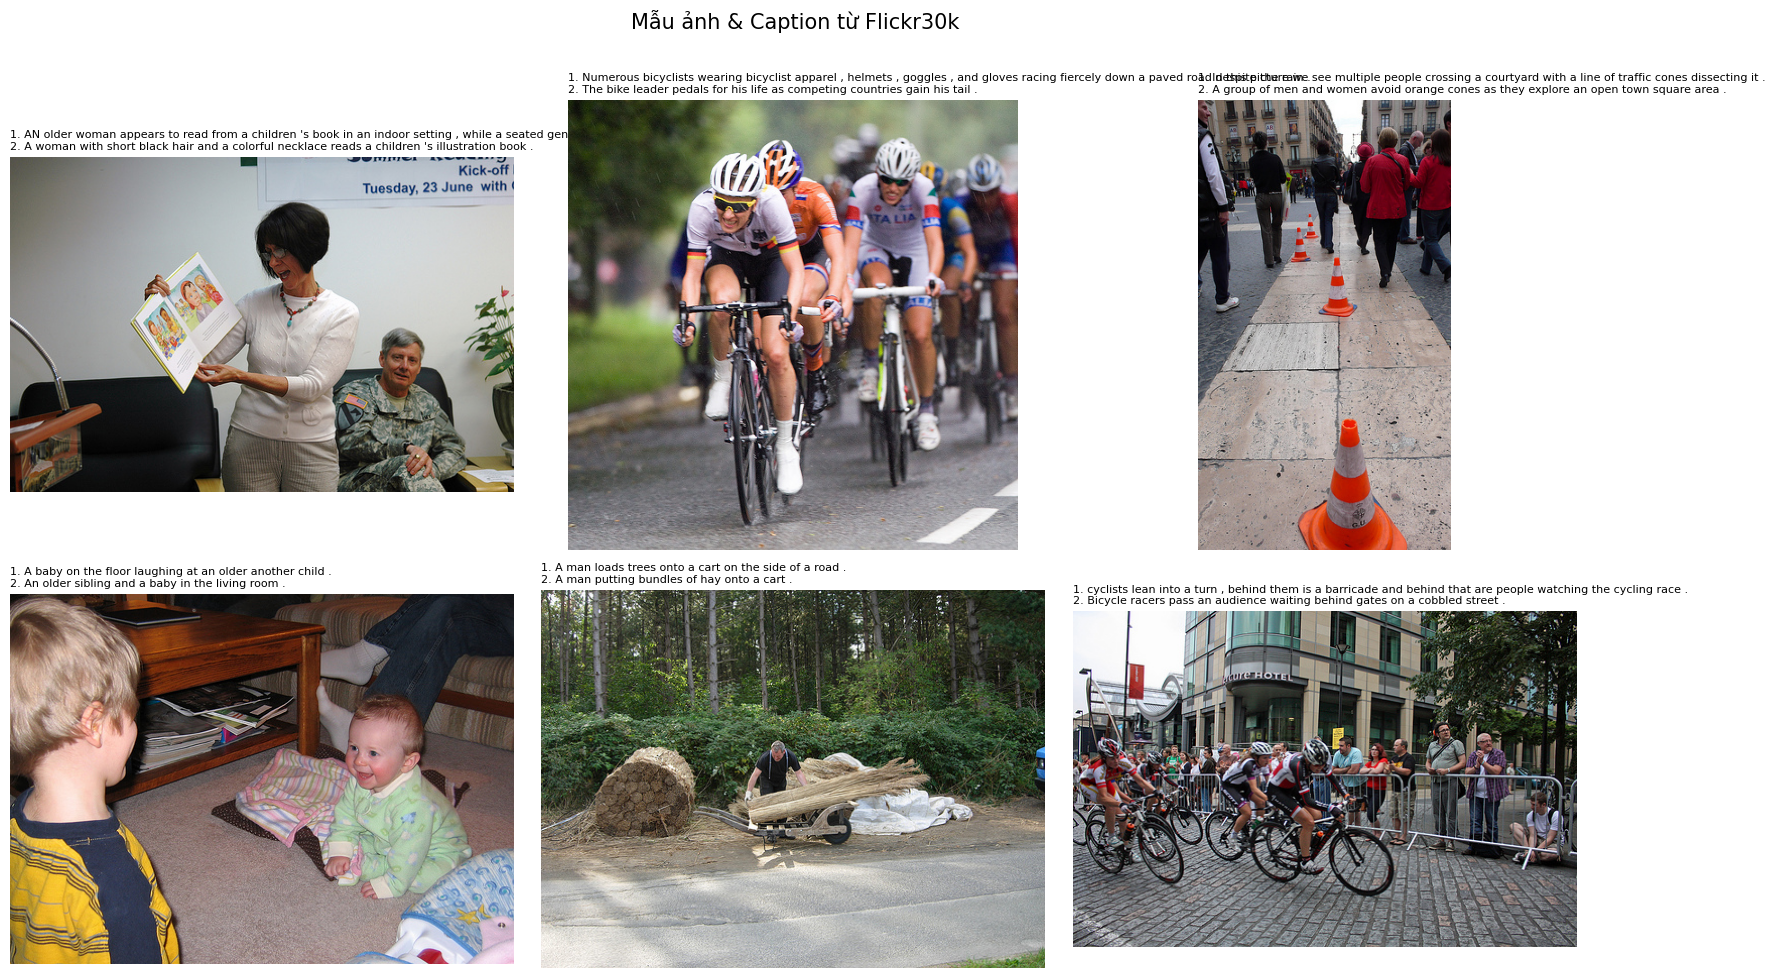

In [44]:
# Hiển thị một số ảnh mẫu
sample_imgs = df['image_name'].drop_duplicates().sample(6, random_state=SEED).tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, img_name in zip(axes.flat, sample_imgs):
    img_path = IMAGES_DIR / img_name
    img = Image.open(img_path).convert('RGB')
    captions = df[df['image_name'] == img_name]['caption'].tolist()
    ax.imshow(img)
    ax.set_title('\n'.join([f'{i+1}. {c}' for i, c in enumerate(captions[:2])]),
                 fontsize=8, loc='left', pad=6)
    ax.axis('off')

plt.suptitle('Mẫu ảnh & Caption từ Flickr30k', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 5. Chia Train / Validation / Test

In [45]:
# Chia theo image (không bị data leakage) — tỉ lệ 8:1:1
all_images = df['image_name'].drop_duplicates().tolist()
random.shuffle(all_images)

n_total = len(all_images)
n_train = int(n_total * 0.8)
n_val   = int(n_total * 0.1)
n_test  = n_total - n_train - n_val

train_imgs = set(all_images[:n_train])
val_imgs   = set(all_images[n_train:n_train + n_val])
test_imgs  = set(all_images[n_train + n_val:])

train_df = df[df['image_name'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image_name'].isin(val_imgs)].reset_index(drop=True)
test_df  = df[df['image_name'].isin(test_imgs)].reset_index(drop=True)

print(f'Tổng  : {n_total:,} ảnh')
print(f'Train : {len(train_imgs):,} ảnh ({len(train_imgs)/n_total*100:.0f}%) | {len(train_df):,} captions')
print(f'Val   : {len(val_imgs):,} ảnh ({len(val_imgs)/n_total*100:.0f}%) | {len(val_df):,} captions')
print(f'Test  : {len(test_imgs):,} ảnh ({len(test_imgs)/n_total*100:.0f}%) | {len(test_df):,} captions')

Tổng  : 31,783 ảnh
Train : 25,426 ảnh (80%) | 127,129 captions
Val   : 3,178 ảnh (10%) | 15,890 captions
Test  : 3,179 ảnh (10%) | 15,895 captions


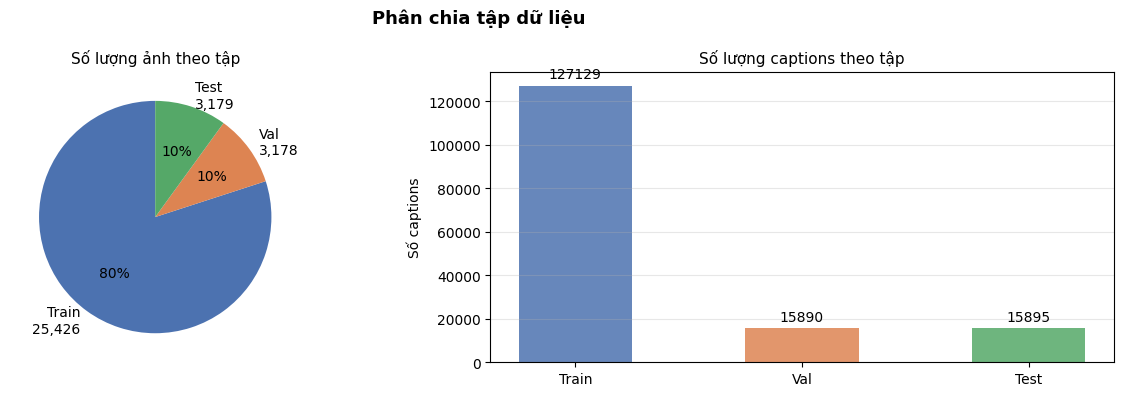

Kiểm tra data leakage:
Train ∩ Val  = 0 ảnh (phải = 0)
Train ∩ Test = 0 ảnh (phải = 0)


In [46]:
# Phân chia Train/Val/Test
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Phân chia tập dữ liệu', fontsize=13, fontweight='bold')

# Pie chart số ảnh
labels_pie = [f'Train\n{len(train_imgs):,}', f'Val\n{len(val_imgs):,}', f'Test\n{len(test_imgs):,}']
sizes = [len(train_imgs), len(val_imgs), len(test_imgs)]
colors = ['#4C72B0', '#DD8452', '#55A868']
axes[0].pie(sizes, labels=labels_pie, colors=colors, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Số lượng ảnh theo tập', fontsize=11)

# Bar chart số captions
split_names = ['Train', 'Val', 'Test']
caption_counts = [len(train_df), len(val_df), len(test_df)]
bars = axes[1].bar(split_names, caption_counts, color=colors, alpha=0.85, width=0.5)
axes[1].bar_label(bars, fmt='%d', padding=3, fontsize=10)
axes[1].set_title('Số lượng captions theo tập', fontsize=11)
axes[1].set_ylabel('Số captions')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Kiểm tra không bị leakage
overlap_tv = train_imgs & val_imgs
overlap_tt = train_imgs & test_imgs
print(f"Kiểm tra data leakage:")
print(f"Train ∩ Val  = {len(overlap_tv)} ảnh (phải = 0)")
print(f"Train ∩ Test = {len(overlap_tt)} ảnh (phải = 0)")


## 6. Dataset & DataLoader

In [47]:
# ── Config ───────────────────────────────────────────────
CFG = {
    'model_name'       : 'Salesforce/blip-image-captioning-base',
    'max_length'       : 40,   # giảm từ 64→40 (Flickr30k avg ~12 từ)
    'batch_size'       : 8,    # batch nhỏ, bù bằng grad accumulation
    'grad_accum_steps' : 4,    # 8×4 = batch ảo 32
    'num_workers'      : 0,    # Kaggle: dùng 0 để ổn định
    # ── Freeze strategy ──────────────────────────────────
    'freeze_epochs'    : 3,
    'lr_phase1'        : 2e-4,
    'lr_phase2'        : 2e-5,
    # ── Early Stopping ───────────────────────────────────
    'patience'         : 3,    # dừng nếu val loss không giảm sau 3 epoch
    # ─────────────────────────────────────────────────────
    'weight_decay'     : 1e-2,
    'epochs'           : 5,   # tăng lên 10, Early Stopping tự dừng đúng lúc
    'warmup_ratio'     : 0.1,
    'grad_clip'        : 1.0,
    'log_interval'     : 100,
    'save_every'       : 1,
}


class Flickr30kDataset(Dataset):

    def __init__(self, dataframe: pd.DataFrame, images_dir: Path,
                 processor: BlipProcessor, max_length: int = 64):
        # Mỗi hàng là 1 (ảnh, caption) pair — ảnh có thể lặp lại
        self.data       = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.processor  = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row     = self.data.iloc[idx]
        img_path = self.images_dir / row['image_name']

        # Load ảnh
        image = Image.open(img_path).convert('RGB')

        # Tiền xử lý: ảnh + caption cùng lúc
        encoding = self.processor(
            images=image,
            text=row['caption'],
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )

        pixel_values   = encoding['pixel_values'].squeeze(0)   # (3, H, W)
        input_ids      = encoding['input_ids'].squeeze(0)       # (L,)
        attention_mask = encoding['attention_mask'].squeeze(0)  # (L,)

        # Labels: -100 tại vị trí padding để bỏ qua khi tính loss
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100

        return {
            'pixel_values'  : pixel_values,
            'input_ids'     : input_ids,
            'attention_mask': attention_mask,
            'labels'        : labels,
        }

In [48]:
# ── Khởi tạo Processor & Datasets ───────────────────────
print('Load BLIP Processor...')
processor = BlipProcessor.from_pretrained(CFG['model_name'])

train_dataset = Flickr30kDataset(train_df, IMAGES_DIR, processor, CFG['max_length'])
val_dataset   = Flickr30kDataset(val_df,   IMAGES_DIR, processor, CFG['max_length'])
test_dataset  = Flickr30kDataset(test_df,  IMAGES_DIR, processor, CFG['max_length'])

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=CFG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)

print(f'Train batches: {len(train_loader):,}')
print(f'Val batches  : {len(val_loader):,}')
print(f'Test batches : {len(test_loader):,}')

# Kiểm tra 1 batch
batch = next(iter(train_loader))
print(f'\nShapes:')
for k, v in batch.items():
    print(f'   {k}: {v.shape}')

Load BLIP Processor...
Train batches: 15,892
Val batches  : 1,987
Test batches : 1,987

Shapes:
   pixel_values: torch.Size([8, 3, 384, 384])
   input_ids: torch.Size([8, 40])
   attention_mask: torch.Size([8, 40])
   labels: torch.Size([8, 40])


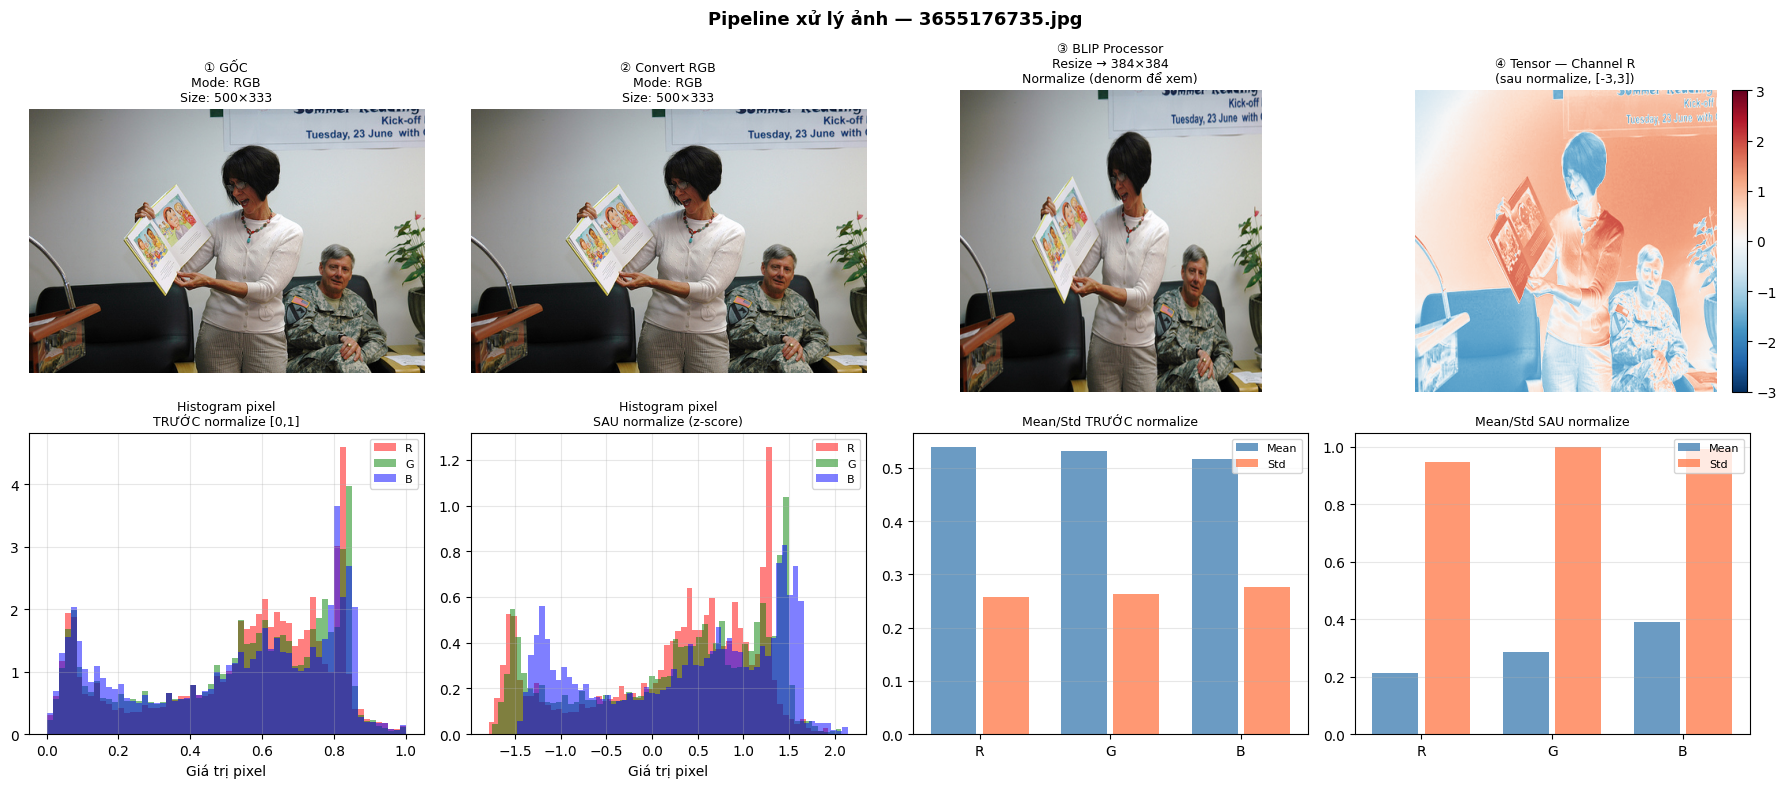

  [3655176735.jpg]
    Mode gốc   : RGB → RGB
    Size gốc   : (500, 333) → 384×384 (BLIP resize)
    Pixel TRƯỚC: mean≈0.529, std≈0.265
    Pixel SAU  : mean≈0.296, std≈0.980



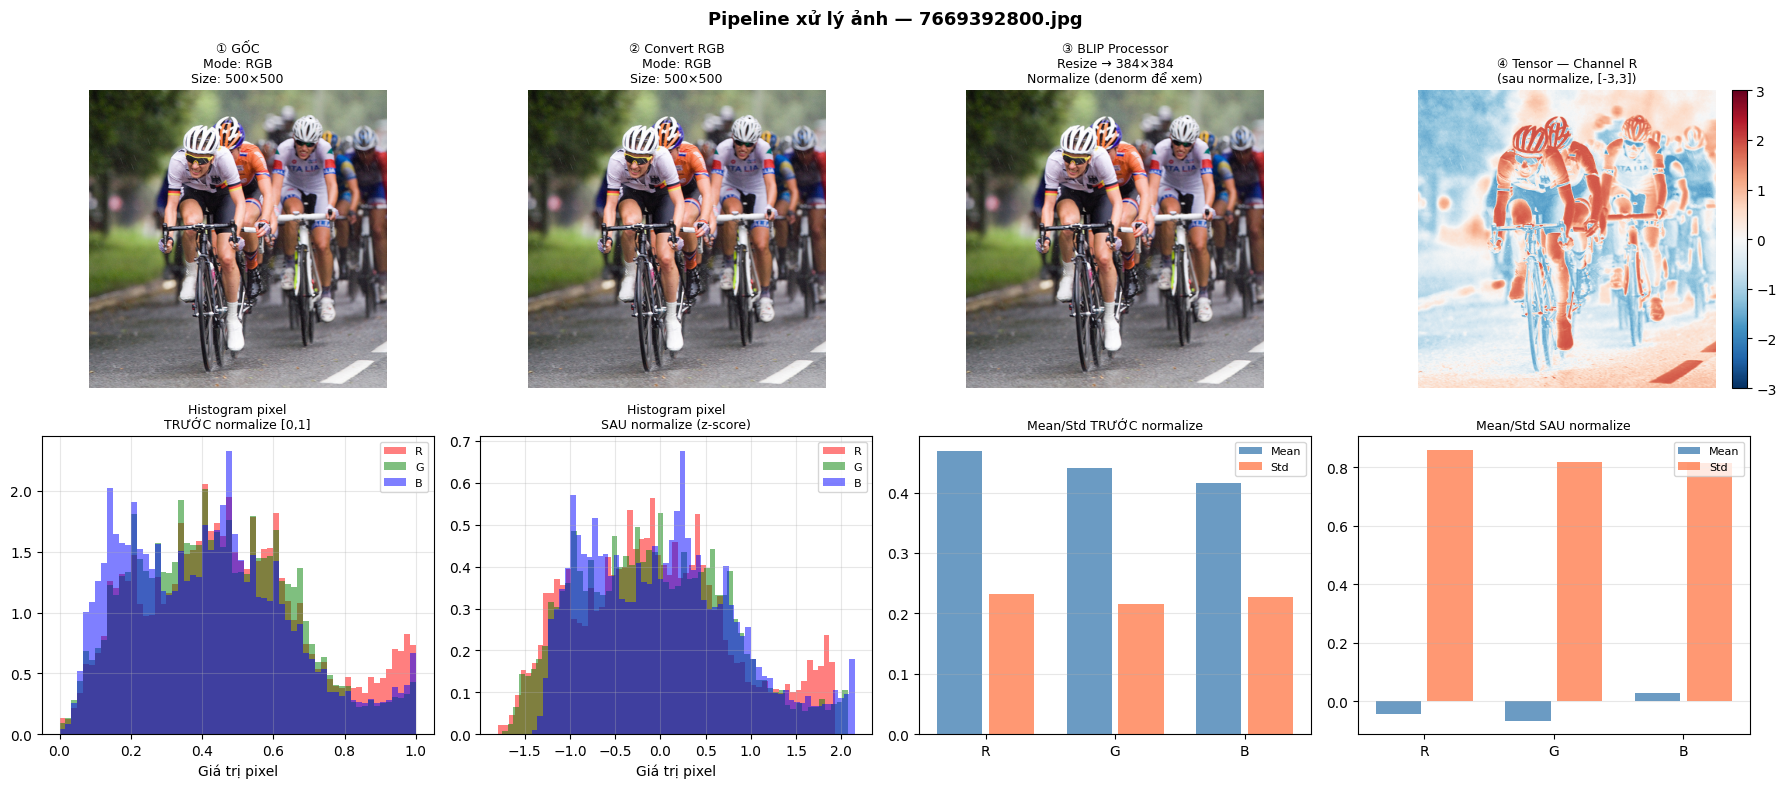

  [7669392800.jpg]
    Mode gốc   : RGB → RGB
    Size gốc   : (500, 500) → 384×384 (BLIP resize)
    Pixel TRƯỚC: mean≈0.442, std≈0.225
    Pixel SAU  : mean≈-0.028, std≈0.830



In [49]:
# Tiền xử lý Ảnh — Pipeline
# Bước: Gốc → Convert RGB → Resize → Normalize
import numpy as np

_demo_imgs = df['image_name'].drop_duplicates().sample(2, random_state=SEED).tolist()
_blip_mean = [0.48145466, 0.4578275,  0.40821073]
_blip_std  = [0.26862954, 0.26130258, 0.27577711]

for img_name in _demo_imgs:
    img_path = IMAGES_DIR / img_name
    raw_img  = Image.open(img_path)          # chưa convert

    # Bước 1: raw
    step1 = raw_img.copy()

    # Bước 2: convert RGB
    step2 = raw_img.convert('RGB')

    # Bước 3: BLIP processor (resize 384 + normalize)
    enc   = processor(images=step2, return_tensors='pt')
    pv    = enc['pixel_values'].squeeze(0)   # (3, H, W) — đã normalize

    # Denormalize để hiển thị
    step3_disp = pv.clone()
    for ch, (m, s) in enumerate(zip(_blip_mean, _blip_std)):
        step3_disp[ch] = step3_disp[ch] * s + m
    step3_disp = step3_disp.clamp(0,1).permute(1,2,0).numpy()

    # Pixel distribution: trước vs sau normalize
    step2_arr = np.array(step2).astype(float) / 255.0  # [0,1]
    pv_np     = pv.permute(1,2,0).numpy()              # normalized

    fig = plt.figure(figsize=(18, 8))
    fig.suptitle(f'Pipeline xử lý ảnh — {img_name}',
                 fontsize=13, fontweight='bold')

    # row 1: ảnh qua từng bước
    # Subplot 1: raw
    ax1 = fig.add_subplot(2, 4, 1)
    try:
        ax1.imshow(step1)
    except Exception:
        ax1.imshow(step1.convert('RGB'))
    ax1.set_title(f'① GỐC\nMode: {raw_img.mode}\nSize: {raw_img.size[0]}×{raw_img.size[1]}',
                  fontsize=9); ax1.axis('off')

    # Subplot 2: RGB
    ax2 = fig.add_subplot(2, 4, 2)
    ax2.imshow(step2)
    ax2.set_title(f'② Convert RGB\nMode: RGB\nSize: {step2.size[0]}×{step2.size[1]}',
                  fontsize=9); ax2.axis('off')

    # Subplot 3: sau BLIP resize + normalize (hiển thị denorm)
    ax3 = fig.add_subplot(2, 4, 3)
    ax3.imshow(step3_disp)
    ax3.set_title(f'③ BLIP Processor\nResize → {pv.shape[1]}×{pv.shape[2]}\nNormalize (denorm để xem)',
                  fontsize=9); ax3.axis('off')

    # Subplot 4: tensor heatmap channel R
    ax4 = fig.add_subplot(2, 4, 4)
    im4 = ax4.imshow(pv_np[:,:,0], cmap='RdBu_r', vmin=-3, vmax=3)
    plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
    ax4.set_title('④ Tensor — Channel R\n(sau normalize, [-3,3])', fontsize=9)
    ax4.axis('off')

    # Row 2: histogram pixel distribution
    colors = ['red','green','blue']
    ch_names = ['R','G','B']

    # Trước normalize
    ax5 = fig.add_subplot(2, 4, 5)
    for ch, (col, name) in enumerate(zip(colors, ch_names)):
        ax5.hist(step2_arr[:,:,ch].flatten(), bins=60, alpha=0.5,
                 color=col, label=name, density=True)
    ax5.set_title('Histogram pixel\nTRƯỚC normalize [0,1]', fontsize=9)
    ax5.set_xlabel('Giá trị pixel'); ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

    # Sau normalize
    ax6 = fig.add_subplot(2, 4, 6)
    for ch, (col, name) in enumerate(zip(colors, ch_names)):
        ax6.hist(pv_np[:,:,ch].flatten(), bins=60, alpha=0.5,
                 color=col, label=name, density=True)
    ax6.set_title('Histogram pixel\nSAU normalize (z-score)', fontsize=9)
    ax6.set_xlabel('Giá trị pixel'); ax6.legend(fontsize=8); ax6.grid(alpha=0.3)

    # Mean/Std bar: trước
    ax7 = fig.add_subplot(2, 4, 7)
    _m_before = [step2_arr[:,:,ch].mean() for ch in range(3)]
    _s_before = [step2_arr[:,:,ch].std()  for ch in range(3)]
    x = range(3)
    ax7.bar([i-0.2 for i in x], _m_before, 0.35, label='Mean', color='steelblue', alpha=0.8)
    ax7.bar([i+0.2 for i in x], _s_before, 0.35, label='Std',  color='coral',     alpha=0.8)
    ax7.set_xticks(list(x)); ax7.set_xticklabels(ch_names)
    ax7.set_title('Mean/Std TRƯỚC normalize', fontsize=9)
    ax7.legend(fontsize=8); ax7.grid(axis='y', alpha=0.3)

    # Mean/Std bar: sau
    ax8 = fig.add_subplot(2, 4, 8)
    _m_after = [pv_np[:,:,ch].mean() for ch in range(3)]
    _s_after = [pv_np[:,:,ch].std()  for ch in range(3)]
    ax8.bar([i-0.2 for i in x], _m_after, 0.35, label='Mean', color='steelblue', alpha=0.8)
    ax8.bar([i+0.2 for i in x], _s_after, 0.35, label='Std',  color='coral',     alpha=0.8)
    ax8.set_xticks(list(x)); ax8.set_xticklabels(ch_names)
    ax8.set_title('Mean/Std SAU normalize', fontsize=9)
    ax8.legend(fontsize=8); ax8.grid(axis='y', alpha=0.3)

    plt.tight_layout(); plt.show()

    print(f"  [{img_name}]")
    print(f"    Mode gốc   : {raw_img.mode} → RGB")
    print(f"    Size gốc   : {raw_img.size} → {pv.shape[1]}×{pv.shape[2]} (BLIP resize)")
    print(f"    Pixel TRƯỚC: mean≈{sum(_m_before)/3:.3f}, std≈{sum(_s_before)/3:.3f}")
    print(f"    Pixel SAU  : mean≈{sum(_m_after)/3:.3f}, std≈{sum(_s_after)/3:.3f}")
    print()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TRƯỚC — Caption dạng text thuần:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [0] 'A man is sitting on an upturned white bucket playing a banjo .'
  [1] 'Spelunkers pose inside a rock cavern while bathed in sunlight from the surface .'
  [2] 'A skateboarder is doing a trick in the air with his skateboard on a red ramp while people stand around looking .'
  [3] 'Man with backpack walks through a crowded park .'

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SAU — Sau khi BLIP Processor tokenize (padding đến max_length=40):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [0] 'A man is sitting on an upturned white bucket playing a banjo'
       Tokens: ['[CLS]', 'a', 'man', 'is', 'sitting', 'on', 'an', 'up', '##turn', '##ed', 'white', 'bucket', 'playing', 'a', 'banjo', '.', '[SEP]']
       IDs   : [101, 1037, 2158, 2003, 3564, 2006, 2019, 203

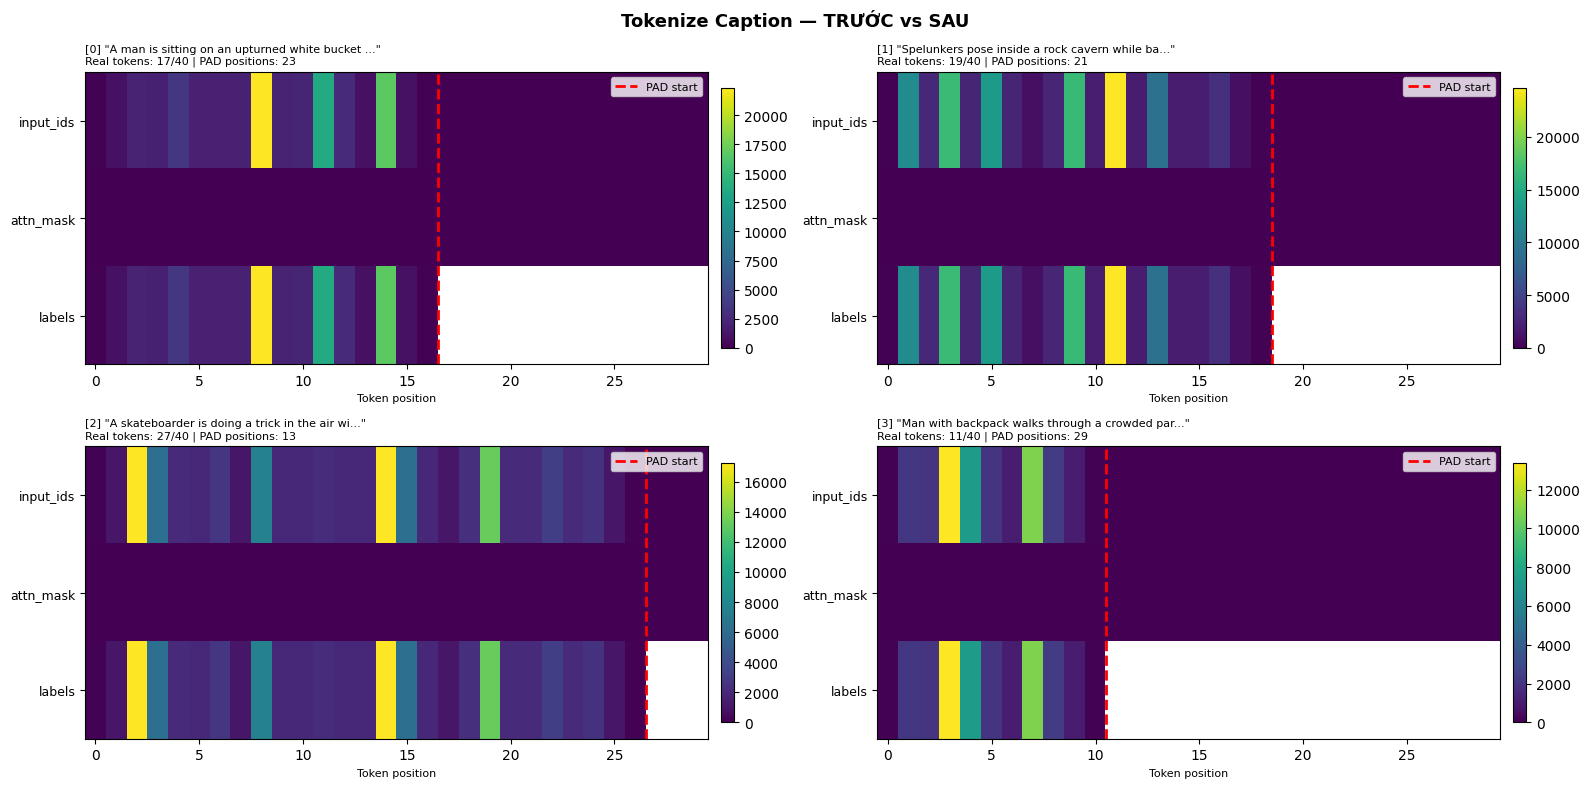

In [50]:
# Tokenize Caption — TRƯỚC và SAU

_sample_captions = df['caption'].sample(4, random_state=SEED).tolist()

print("━" * 70)
print("TRƯỚC — Caption dạng text thuần:")
print("━" * 70)
for i, cap in enumerate(_sample_captions):
    print(f"  [{i}] '{cap}'")

print()
print("━" * 70)
print("SAU — Sau khi BLIP Processor tokenize (padding đến max_length=40):")
print("━" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Tokenize Caption — TRƯỚC vs SAU', fontsize=13, fontweight='bold')

for idx, (ax, cap) in enumerate(zip(axes.flat, _sample_captions)):
    enc = processor(
        text=cap,
        padding='max_length',
        truncation=True,
        max_length=CFG['max_length'],
        return_tensors='pt'
    )
    input_ids      = enc['input_ids'].squeeze(0).numpy()       # (max_length,)
    attention_mask = enc['attention_mask'].squeeze(0).numpy()  # (max_length,)
    labels         = input_ids.copy()
    labels[attention_mask == 0] = -100                         # PAD → -100

    # Token strings để hiển thị
    tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)
    real_len = int(attention_mask.sum())

    # Vẽ heatmap input_ids | attention_mask | labels
    display_len = min(CFG['max_length'], 30)
    data = [
        input_ids[:display_len],
        attention_mask[:display_len],
        labels[:display_len]
    ]
    import numpy as np
    data_np = np.array(data, dtype=float)
    # labels có -100 → đặt thành NaN để màu khác
    labels_disp = labels[:display_len].astype(float)
    labels_disp[labels_disp == -100] = float('nan')
    data_np[2] = labels_disp

    im = ax.imshow(data_np, aspect='auto', cmap='viridis',
                   vmin=0, vmax=max(input_ids.max(), 1))
    ax.set_yticks([0,1,2])
    ax.set_yticklabels(['input_ids','attn_mask','labels'], fontsize=9)
    ax.set_xlabel('Token position', fontsize=8)
    ax.set_title(
        f'[{idx}] "{cap[:45]}{"..." if len(cap) > 45 else ""}"\n'
        f'Real tokens: {real_len}/{CFG["max_length"]} | PAD positions: {CFG["max_length"]-real_len}',
        fontsize=8, loc='left'
    )
    # Đánh dấu ranh giới real / PAD
    ax.axvline(real_len - 0.5, color='red', linewidth=2, linestyle='--', label='PAD start')
    ax.legend(fontsize=8, loc='upper right')
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)

    # In chi tiết
    print(f"  [{idx}] '{cap[:60]}'")
    print(f"       Tokens: {tokens[:real_len]}")
    print(f"       IDs   : {input_ids[:real_len].tolist()}")
    print(f"       Labels: {labels[:real_len].tolist()}")
    print(f"       PAD ({CFG['max_length']-real_len} vị trí) → labels=-100 (bỏ qua khi tính loss)")
    print()

plt.tight_layout(); plt.show()


Shapes trong 1 batch:
   pixel_values   : (8, 3, 384, 384)  dtype=torch.float32
   input_ids      : (8, 40)  dtype=torch.int64
   attention_mask : (8, 40)  dtype=torch.int64
   labels         : (8, 40)  dtype=torch.int64


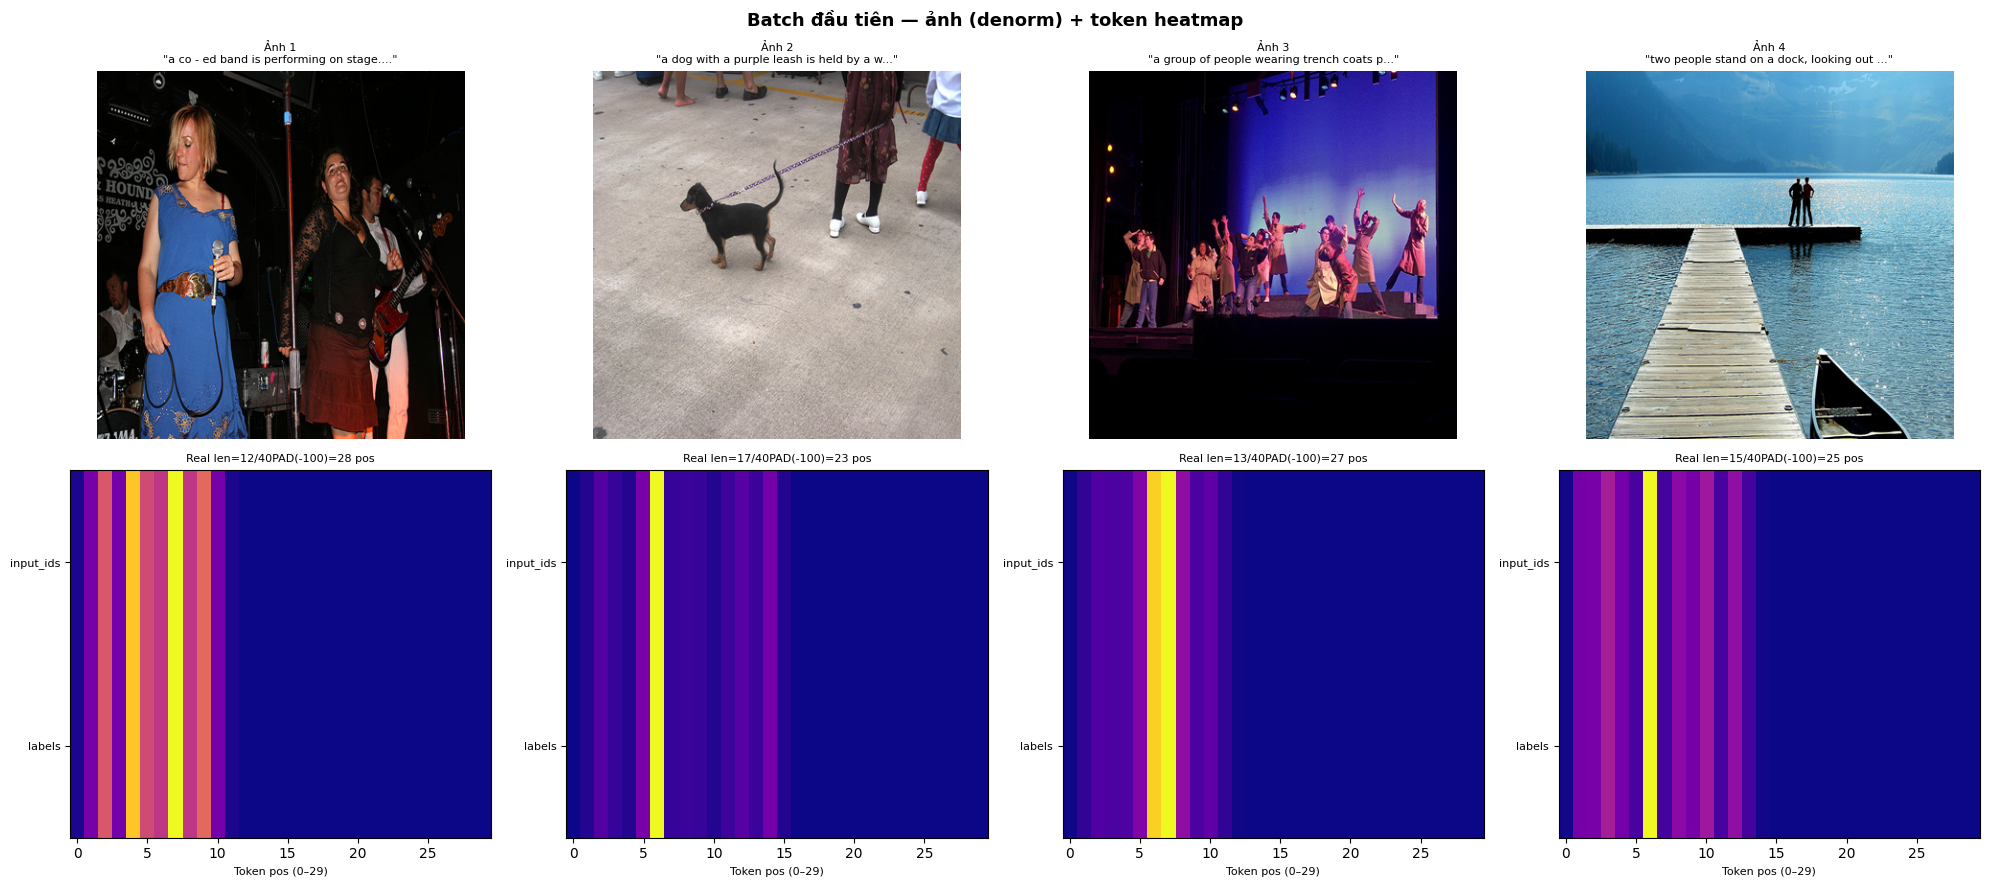

In [51]:
#  Batch — ảnh + caption + labels
_batch = next(iter(train_loader))
_blip_mean = [0.48145466, 0.4578275,  0.40821073]
_blip_std  = [0.26862954, 0.26130258, 0.27577711]

print("Shapes trong 1 batch:")
for k, v in _batch.items():
    print(f"   {k:15s}: {tuple(v.shape)}  dtype={v.dtype}")

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Batch đầu tiên — ảnh (denorm) + token heatmap',
             fontsize=13, fontweight='bold')

_pv   = _batch['pixel_values']
_ids  = _batch['input_ids']
_mask = _batch['attention_mask']
_lbl  = _batch['labels']

for i in range(4):
    # Hàng trên: ảnh đã denormalize
    inv = _pv[i].clone()
    for ch, (m, s) in enumerate(zip(_blip_mean, _blip_std)):
        inv[ch] = inv[ch] * s + m
    inv = inv.clamp(0,1).permute(1,2,0).numpy()
    decoded = processor.decode(_ids[i], skip_special_tokens=True)
    axes[0, i].imshow(inv)
    axes[0, i].set_title(f'Ảnh {i+1}\n"{decoded[:40]}..."', fontsize=8)
    axes[0, i].axis('off')

    # Hàng dưới: heatmap input_ids / labels
    import numpy as np
    _id_np  = _ids[i].numpy().astype(float)
    _lbl_np = _lbl[i].numpy().astype(float)
    _lbl_disp = _lbl_np.copy()
    _lbl_disp[_lbl_disp == -100] = 0   # hiển thị -100 thành 0
    data = np.stack([_id_np, _lbl_disp])[:, :30]
    im = axes[1, i].imshow(data, aspect='auto', cmap='plasma', vmin=0)
    axes[1, i].set_yticks([0,1]); axes[1, i].set_yticklabels(['input_ids','labels'], fontsize=8)
    axes[1, i].set_title(
        f'Real len={int(_mask[i].sum())}/{_ids.shape[1]}'
        f'PAD(-100)={int((_lbl[i]==-100).sum())} pos',
        fontsize=8)
    axes[1, i].set_xlabel('Token pos (0–29)', fontsize=8)

plt.tight_layout(); plt.show()


## 7. Khởi tạo Model BLIP

In [52]:
print('Load BLIP model...')
model = BlipForConditionalGeneration.from_pretrained(CFG['model_name'])

model = torch.compile(model)

model = model.to(DEVICE)

# Freeze / Unfreeze 
def freeze_vision_encoder(model):
    for param in model.vision_model.parameters():
        param.requires_grad = False
    # Đảm bảo text decoder vẫn trainable
    for param in model.text_decoder.parameters():
        param.requires_grad = True

def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True

def count_trainable(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# Phase 1: Freeze vision encoder
freeze_vision_encoder(model)
total, trainable = count_trainable(model)

print(f'\nTổng tham số        : {total/1e6:.1f}M')
print(f'  Trainable (Phase 1) : {trainable/1e6:.1f}M  (text decoder only)')
print(f'  Frozen              : {(total-trainable)/1e6:.1f}M  (vision encoder)')
print(f'  VRAM hiện tại       : {torch.cuda.memory_allocated()/1e9:.2f} GB')

Load BLIP model...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic


Tổng tham số        : 247.4M
  Trainable (Phase 1) : 161.4M  (text decoder only)
  Frozen              : 86.1M  (vision encoder)
  VRAM hiện tại       : 0.00 GB


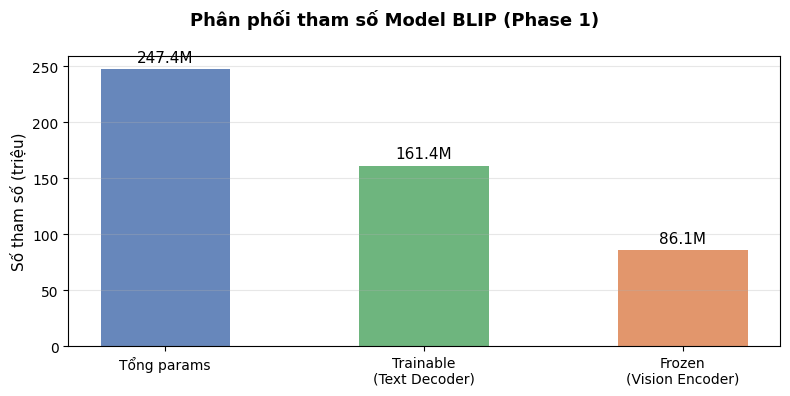

Model: OptimizedModule
   Tổng params      : 247.4M
   Trainable Phase 1: 161.4M  (text decoder)
   Frozen           : 86.1M  (vision encoder)
   Device: CPU


In [57]:

# Thông tin Model BLIP
total, trainable = count_trainable(model)
frozen = total - trainable

# Bar chart params
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Phân phối tham số Model BLIP (Phase 1)', fontsize=13, fontweight='bold')
categories = ['Tổng params', 'Trainable\n(Text Decoder)', 'Frozen\n(Vision Encoder)']
values = [total/1e6, trainable/1e6, frozen/1e6]
colors = ['#4C72B0', '#55A868', '#DD8452']
bars = ax.bar(categories, values, color=colors, alpha=0.85, width=0.5)
ax.bar_label(bars, fmt='%.1fM', padding=3, fontsize=11)
ax.set_ylabel('Số tham số (triệu)', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Model: {type(model).__name__}")
print(f"   Tổng params      : {total/1e6:.1f}M")
print(f"   Trainable Phase 1: {trainable/1e6:.1f}M  (text decoder)")
print(f"   Frozen           : {frozen/1e6:.1f}M  (vision encoder)")
print(f"   VRAM hiện tại    : {torch.cuda.memory_allocated()/1e9:.2f} GB" if torch.cuda.is_available() else "   Device: CPU")


## 8. Optimizer, Scheduler & Mixed Precision

In [58]:
# Hàm tạo optimizer theo phase
no_decay = ['bias', 'LayerNorm.weight', 'layer_norm.weight']

def build_optimizer(model, lr):
    param_groups = [
        {'params': [p for n, p in model.named_parameters()
                    if p.requires_grad and not any(nd in n for nd in no_decay)],
         'weight_decay': CFG['weight_decay']},
        {'params': [p for n, p in model.named_parameters()
                    if p.requires_grad and any(nd in n for nd in no_decay)],
         'weight_decay': 0.0},
    ]
    return AdamW(param_groups, lr=lr)

def build_scheduler(optimizer, num_epochs, warmup_ratio=0.1):
    total_steps  = len(train_loader) * num_epochs
    warmup_steps = int(total_steps * warmup_ratio)
    return get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    ), total_steps, warmup_steps

# Khởi tạo Phase 1 (vision frozen)
optimizer_p1 = build_optimizer(model, CFG['lr_phase1'])
scheduler_p1, steps_p1, warmup_p1 = build_scheduler(
    optimizer_p1, CFG['freeze_epochs'], CFG['warmup_ratio']
)

# AMP scaler dùng chung cả 2 phase
scaler = torch.cuda.amp.GradScaler()

print('Phase 1 Optimizer:')
print(f'   lr={CFG["lr_phase1"]}  |  epochs={CFG["freeze_epochs"]}  |  '
      f'steps={steps_p1:,}  |  warmup={warmup_p1}')
print(f'\n   Phase 2 sẽ được tạo sau khi unfreeze ở epoch {CFG["freeze_epochs"]+1}')

Phase 1 Optimizer:
   lr=0.0002  |  epochs=3  |  steps=47,676  |  warmup=4767

   Phase 2 sẽ được tạo sau khi unfreeze ở epoch 4


## 9. Training Loop

In [55]:
def train_epoch(model, loader, optimizer, scheduler, scaler, epoch):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f'Epoch {epoch} [Train]', leave=False)
    optimizer.zero_grad()                              # reset ở ngoài loop

    for step, batch in enumerate(pbar):
        pixel_values   = batch['pixel_values'].to(DEVICE)
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        with torch.cuda.amp.autocast():
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            # chia loss cho số bước tích lũy
            loss = outputs.loss / CFG['grad_accum_steps']

        scaler.scale(loss).backward()

        # chỉ update sau khi tích lũy đủ grad_accum_steps bước
        if (step + 1) % CFG['grad_accum_steps'] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_loss += loss.item() * CFG['grad_accum_steps']  # khôi phục loss gốc để log
        pbar.set_postfix({'loss': f'{loss.item() * CFG["grad_accum_steps"]:.4f}',
                          'lr': f'{scheduler.get_last_lr()[0]:.2e}'})

    return total_loss / len(loader)


@torch.no_grad()
def validate_epoch(model, loader, epoch):
    model.eval()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f'Epoch {epoch} [Val]', leave=False)

    for batch in pbar:
        pixel_values   = batch['pixel_values'].to(DEVICE)
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        with torch.cuda.amp.autocast():
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
        total_loss += outputs.loss.item()
        pbar.set_postfix({'val_loss': f'{outputs.loss.item():.4f}'})

    return total_loss / len(loader)

In [56]:
history = {
    'epoch': [], 'phase': [],
    'train_loss': [], 'val_loss': [],
    'trainable_params': [], 'lr': []
}
best_val_loss    = float('inf')
patience_counter = 0                           # Early Stopping counter

# Dùng Phase 1 optimizer/scheduler ngay từ đầu
optimizer = optimizer_p1
scheduler = scheduler_p1

print('Bắt đầu training với chiến lược Freeze/Unfreeze + Early Stopping\n')
print(f'   Phase 1 (Frozen Vision): Epoch 1 → {CFG["freeze_epochs"]}  |  lr={CFG["lr_phase1"]}')
print(f'   Phase 2 (Full Finetune): Epoch {CFG["freeze_epochs"]+1} → {CFG["epochs"]}  |  lr={CFG["lr_phase2"]}')
print(f'   Early Stopping patience: {CFG["patience"]} epoch')
print()

for epoch in range(1, CFG['epochs'] + 1):

    # ── Chuyển phase ──────────────────────────────────────
    if epoch == CFG['freeze_epochs'] + 1:
        print('\n' + '='*60)
        print(f'PHASE 2: Unfreeze toàn bộ model tại Epoch {epoch}')
        unfreeze_all(model)
        total, trainable = count_trainable(model)
        print(f'   Trainable params: {trainable/1e6:.1f}M / {total/1e6:.1f}M')

        # Tạo optimizer & scheduler mới với lr thấp hơn
        optimizer = build_optimizer(model, CFG['lr_phase2'])
        remaining_epochs = CFG['epochs'] - CFG['freeze_epochs']
        scheduler, steps_p2, warmup_p2 = build_scheduler(
            optimizer, remaining_epochs, CFG['warmup_ratio']
        )
        print(f'   Optimizer mới: lr={CFG["lr_phase2"]}  |  steps={steps_p2:,}  |  warmup={warmup_p2}')
        print('='*60 + '\n')

    # Xác định phase hiện tại
    phase = 1 if epoch <= CFG['freeze_epochs'] else 2
    _, trainable = count_trainable(model)

    print(f'[Phase {phase}] Epoch {epoch}/{CFG["epochs"]}  |  '
          f'Trainable: {trainable/1e6:.1f}M params')

    # ── Train ─────────────────────────────────────────────
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, scaler, epoch)
    val_loss   = validate_epoch(model, val_loader, epoch)
    current_lr = scheduler.get_last_lr()[0]

    history['epoch'].append(epoch)
    history['phase'].append(phase)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['trainable_params'].append(trainable)
    history['lr'].append(current_lr)

    print(f'   Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}  |  lr: {current_lr:.2e}')

    # ── Checkpoint ────────────────────────────────────────
    if epoch % CFG['save_every'] == 0:
        ckpt_path = CHECKPOINT_DIR / f'epoch_{epoch:02d}_phase{phase}.pt'
        torch.save({
            'epoch'               : epoch,
            'phase'               : phase,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss'            : val_loss,
            'config'              : CFG,
        }, ckpt_path)
        print(f'   💾 Saved: {ckpt_path.name}')

    # ── Best model & Early Stopping ───────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0                       # reset khi có cải thiện
        model.save_pretrained(CHECKPOINT_DIR / 'best_model')
        processor.save_pretrained(CHECKPOINT_DIR / 'best_model')
        print(f'Best model! Val Loss: {val_loss:.4f}')
    else:
        patience_counter += 1
        print(f'No improvement  '
              f'(patience {patience_counter}/{CFG["patience"]})  '
              f'| Best: {best_val_loss:.4f}')
        if patience_counter >= CFG['patience']:
            print(f'\n Early Stopping tại Epoch {epoch}!'
                  f' Val loss không cải thiện sau {CFG["patience"]} epoch.')
            print(f'   Best Val Loss đạt được: {best_val_loss:.4f}')
            break

print('\nTraining hoàn tất!')

Bắt đầu training với chiến lược Freeze/Unfreeze + Early Stopping

   Phase 1 (Frozen Vision): Epoch 1 → 3  |  lr=0.0002
   Phase 2 (Full Finetune): Epoch 4 → 5  |  lr=2e-05
   Early Stopping patience: 3 epoch

[Phase 1] Epoch 1/5  |  Trainable: 161.4M params


Epoch 1 [Train]:   0%|          | 0/15892 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ── Vẽ learning curves có đánh dấu phase ────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs_range = history['epoch']
phase_colors = ['steelblue' if p == 1 else 'darkorange' for p in history['phase']]

# ── Loss curves ───────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', color='steelblue', lw=2)
ax.plot(epochs_range, history['val_loss'],   's--', label='Val Loss',   color='coral',     lw=2)
ax.axvline(CFG['freeze_epochs'] + 0.5, color='gray', linestyle=':', lw=1.5,
           label=f'Unfreeze (Epoch {CFG["freeze_epochs"]+1})')
ax.fill_betweenx([0, max(history['train_loss'])*1.1],
                 0.5, CFG['freeze_epochs'] + 0.5,
                 alpha=0.06, color='steelblue', label='Phase 1 (frozen)')
ax.fill_betweenx([0, max(history['train_loss'])*1.1],
                 CFG['freeze_epochs'] + 0.5, CFG['epochs'] + 0.5,
                 alpha=0.06, color='darkorange', label='Phase 2 (full)')
ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Learning Curves — Freeze/Unfreeze', fontsize=13)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── LR schedule ───────────────────────────────────────────
ax2 = axes[1]
bars = ax2.bar(epochs_range, history['lr'], color=phase_colors, alpha=0.8, width=0.6)
ax2.axvline(CFG['freeze_epochs'] + 0.5, color='gray', linestyle=':', lw=1.5)
ax2.set_xlabel('Epoch', fontsize=12); ax2.set_ylabel('Learning Rate', fontsize=12)
ax2.set_title('Learning Rate per Epoch', fontsize=13)
from matplotlib.patches import Patch
legend_els = [Patch(color='steelblue', alpha=0.8, label='Phase 1 (frozen vision)'),
              Patch(color='darkorange', alpha=0.8, label='Phase 2 (full finetune)')]
ax2.legend(handles=legend_els, fontsize=9); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Đánh giá: BLEU Score trên Test Set

In [ ]:
@torch.no_grad()
def generate_captions_batch(model, processor, image_paths: list,
                             max_new_tokens: int = 64) -> list:
    """Sinh caption cho một batch ảnh."""
    images = [Image.open(p).convert('RGB') for p in image_paths]
    inputs = processor(images=images, return_tensors='pt').to(DEVICE)

    with torch.cuda.amp.autocast():
        out_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
        )
    return processor.batch_decode(out_ids, skip_special_tokens=True)


def compute_bleu(references_dict: dict, hypotheses_dict: dict):
    """
    references_dict : {img_name: [list_of_ref_captions]}
    hypotheses_dict : {img_name: generated_caption}
    Trả về BLEU-1,2,3,4
    """
    refs, hyps = [], []
    for img in hypotheses_dict:
        if img not in references_dict:
            continue
        ref_tokens  = [nltk.word_tokenize(r.lower()) for r in references_dict[img]]
        hyp_tokens  = nltk.word_tokenize(hypotheses_dict[img].lower())
        refs.append(ref_tokens)
        hyps.append(hyp_tokens)

    sf = SmoothingFunction().method1
    scores = {}
    for n in [1, 2, 3, 4]:
        weights = tuple([1/n] * n + [0] * (4 - n))
        scores[f'BLEU-{n}'] = corpus_bleu(refs, hyps, weights=weights,
                                            smoothing_function=sf)
    return scores

In [ ]:
# ── Load best model ───────────────────────────────────────
print('Load best model...')
best_model = BlipForConditionalGeneration.from_pretrained(
    CHECKPOINT_DIR / 'best_model'
).to(DEVICE)
best_model.eval()

# ── Sinh caption trên test set ────────────────────────────
EVAL_BATCH = 8
test_images = test_df['image_name'].drop_duplicates().tolist()

# References: image_name → list[str]
refs_dict = test_df.groupby('image_name')['caption'].apply(list).to_dict()

hyps_dict = {}
for i in tqdm(range(0, len(test_images), EVAL_BATCH), desc='Generating captions'):
    batch_names = test_images[i:i + EVAL_BATCH]
    batch_paths = [IMAGES_DIR / n for n in batch_names]
    captions    = generate_captions_batch(best_model, processor, batch_paths)
    for name, cap in zip(batch_names, captions):
        hyps_dict[name] = cap

# ── Tính BLEU ─────────────────────────────────────────────
bleu_scores = compute_bleu(refs_dict, hyps_dict)

print('\n Kết quả BLEU trên Test Set:')
for k, v in bleu_scores.items():
    print(f'   {k}: {v:.4f}  ({v*100:.2f}%)')

In [ ]:
# ── Vẽ BLEU scores ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
names  = list(bleu_scores.keys())
values = [v * 100 for v in bleu_scores.values()]
bars = ax.bar(names, values, color=['#4C72B0','#DD8452','#55A868','#C44E52'], width=0.5)
ax.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=11)
ax.set_ylim(0, max(values) * 1.3)
ax.set_ylabel('BLEU Score (%)', fontsize=12)
ax.set_title('BLEU Scores — BLIP on Flickr30k Test Set', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Demo: Sinh Caption cho Ảnh

In [ ]:
def demo_captions(model, processor, image_names: list,
                  images_dir: Path, refs_dict: dict, n: int = 6):
    """Hiển thị ảnh kèm caption sinh ra vs reference."""
    samples = random.sample(image_names, min(n, len(image_names)))
    paths   = [images_dir / s for s in samples]
    generated = generate_captions_batch(model, processor, paths)

    cols = 3
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
    axes = axes.flat

    for ax, img_name, gen_cap in zip(axes, samples, generated):
        img = Image.open(images_dir / img_name).convert('RGB')
        ref = refs_dict.get(img_name, [''])[0]

        ax.imshow(img)
        ax.axis('off')
        title = (f'{gen_cap}\n\n'
                 f'{ref}')
        ax.set_title(title, fontsize=8.5, loc='left', pad=6,
                     wrap=True)

    # Ẩn axes thừa
    for ax in axes:
        ax.axis('off')

    plt.suptitle('= Generated   |   = Reference', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


demo_captions(best_model, processor, test_images, IMAGES_DIR, refs_dict)

## 12. Inference: Ảnh Tùy Chỉnh (Upload hoặc URL)

In [ ]:
import requests
from io import BytesIO

def caption_from_url(url: str) -> str:
    response = requests.get(url, timeout=10)
    image = Image.open(BytesIO(response.content)).convert('RGB')
    inputs = processor(images=image, return_tensors='pt').to(DEVICE)
    with torch.cuda.amp.autocast():
        out = best_model.generate(**inputs, max_new_tokens=64, num_beams=4)
    caption = processor.decode(out[0], skip_special_tokens=True)

    # Hiển thị
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(f'{caption}', fontsize=11, pad=10)
    plt.tight_layout()
    plt.show()
    return caption


# Thử với ảnh từ URL
TEST_URL = 'https://upload.wikimedia.org/wikipedia/commons/thumb/4/43/Cute_dog.jpg/320px-Cute_dog.jpg'
cap = caption_from_url(TEST_URL)
print(f'Caption: {cap}')

## 13. Lưu & Load Model


In [ ]:
# ── Lưu toàn bộ model + processor ────────────────────────
FINAL_SAVE_PATH = CHECKPOINT_DIR / 'final_model'
best_model.save_pretrained(FINAL_SAVE_PATH)
processor.save_pretrained(FINAL_SAVE_PATH)
print(f' Model saved to: {FINAL_SAVE_PATH}')

# ── Để load lại ───────────────────────────────────────────
# model = BlipForConditionalGeneration.from_pretrained(FINAL_SAVE_PATH)
# processor = BlipProcessor.from_pretrained(FINAL_SAVE_PATH)

---
## 📌 Tóm tắt Pipeline

| Bước | Chi tiết |
|------|----------|
| **Dataset** | Flickr30k (~31k ảnh, 5 captions/ảnh) |
| **Model** | BLIP `blip-image-captioning-base` (~247M params) |
| **Phase 1** | Epoch 1–3: Freeze vision encoder, chỉ train text decoder (lr=2e-4) |
| **Phase 2** | Epoch 4–5: Unfreeze toàn bộ, fine-tune nhẹ (lr=2e-5) |
| **Optimizer** | AdamW + Linear Warmup (riêng cho mỗi phase) |
| **AMP** | `torch.cuda.amp` — giảm VRAM, tăng tốc |
| **Evaluation** | BLEU-1/2/3/4 |
| **Inference** | URL, upload file, hoặc test set |

## Tự động lưu & Download Model

In [ ]:
import shutil, os
from pathlib import Path

MODEL_DIR = Path('/kaggle/working/blip_checkpoints/best_model')
ZIP_OUT   = '/kaggle/working/blip_best_model'

if MODEL_DIR.exists():
    print('Nening model...')
    shutil.make_archive(ZIP_OUT, 'zip', str(MODEL_DIR))
    size_mb = os.path.getsize(ZIP_OUT + '.zip') / 1e6
    print(f'Da luu: blip_best_model.zip ({size_mb:.0f} MB)')
    print('Go Output tab ben phai -> tai file .zip ve may')
else:
    # Tim best_model o vi tri khac
    found = False
    for p in Path('/kaggle/working').rglob('config.json'):
        if 'best_model' in str(p) or 'checkpoint' in str(p):
            shutil.make_archive(ZIP_OUT, 'zip', str(p.parent))
            print(f'Tim thay tai: {p.parent}')
            found = True
            break
    if not found:
        print('Khong tim thay model — kiem tra CHECKPOINT_DIR')


### Cach tai file ve may
1. Nhin sang **panel ben phai** -> tab **Output**
2. Tim file `.zip` -> nhan **Download**
3. Hoac **Save Version** -> commit -> vao Output tab

> File nam tai `/kaggle/working/` — luon co san sau khi notebook commit.